In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
# [1] เตรียมเครื่องมือ
!pip install ultralytics roboflow

# [2] โหลดข้อมูล
from roboflow import Roboflow
rf = Roboflow(api_key="FMA0Le006ewZfxRCJvWM")
project = rf.workspace("kasetsart-university-ysai4").project("leaf-detection-76sw2")
dataset = project.version(11).download("yolov8")

# [3] เทรน AI ด้วยการ์ดจอ GPU
from ultralytics import YOLO
import os
from google.colab import files

print("🚀 เริ่มเทรนแบบติดจรวดด้วย GPU...")
model = YOLO('yolov8n.pt')

results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    patience=20,
    optimizer='AdamW',
    augment=True,
    lr0=0.001,
    multi_scale=True,
    mosaic=1.0,
    mixup=0.2,
    copy_paste=0.1,
    project="LeafDetection",
    name="LeafModel_v2",
    seed=42
)

# [4] ดาวน์โหลดน้ำหนักโมเดล (แก้ไขใหม่)
import os
from google.colab import files
import glob

# Path ใหม่ตามที่คุณตั้งไว้
weights_path = "/content/LeafDetection/LeafModel_v2/weights/best.pt"

if os.path.exists(weights_path):
    print("✅ พบไฟล์ best.pt แล้ว!")
    print("กำลังดาวน์โหลดลงเครื่องคุณ...")
    files.download(weights_path)
else:
    print("⚠️ ยังไม่พบ best.pt ที่ path นี้")
    print(f"Path ที่กำลังตรวจ: {weights_path}")

    # ช่วยตรวจสอบว่ามีไฟล์อะไรบ้าง
    print("\n🔍 ตรวจสอบโฟลเดอร์ weights:")
    !ls -la /content/LeafDetection/LeafModel_v2/weights/

    # ลองหาแบบกว้างๆ
    found = glob.glob("/content/LeafDetection/**/best.pt", recursive=True)
    if found:
        print(f"\n✅ พบไฟล์ที่: {found[0]}")
        files.download(found[0])
    else:
        print("\n❌ ยังไม่พบไฟล์ best.pt เลย อาจจะกำลังเทรนอยู่หรือเกิดข้อผิดพลาด")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 97.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 145.7 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Leaf-Detection-11 in yolov8:: 100%|██████████| 3491/3491 [00:01<00:00, 2829.53it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🚀 เริ่มเทรนแบบติดจรวดด้วย GPU...
Ultralytics 8.4.48 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Leaf-Detection-11/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=Fal

In [18]:
#โหลดไฟล์ best.pt จาก cell นี้
import os
import shutil
from google.colab import files
import glob

# กำหนด path
source_path = "/content/LeafDetection/LeafModel_v2/weights/best.pt"
drive_path = "/content/drive/MyDrive/LeafModel_v2/best.pt"

# ตรวจสอบและ copy ไป Drive
if os.path.exists(source_path):
    # สร้างโฟลเดอร์ใน Drive ถ้ายังไม่มี
    os.makedirs("/content/drive/MyDrive/LeafModel_v2", exist_ok=True)

    shutil.copy(source_path, drive_path)
    print("✅ บันทึกไฟล์ลง Google Drive สำเร็จ!")
    print(f"📍 เก็บที่: {drive_path}")

    # ดาวน์โหลดลงเครื่องด้วย
    print("📥 กำลังดาวน์โหลดลงคอมพิวเตอร์...")
    files.download(source_path)

else:
    print("❌ ยังไม่พบ best.pt")
    !ls -la /content/LeafDetection/LeafModel_v2/weights/

    # ลองหาแบบกว้าง
    found = glob.glob("/content/**/best.pt", recursive=True)
    if found:
        print(f"✅ พบไฟล์ที่: {found[0]}")
        files.download(found[0])

❌ ยังไม่พบ best.pt
ls: cannot access '/content/LeafDetection/LeafModel_v2/weights/': No such file or directory
✅ พบไฟล์ที่: /content/runs/detect/LeafDetection/LeafModel_v2/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
#ตรวจสอบไฟล์ best.pt ว่าสามารถเรียกหาได้มั้ย
import glob
import os

print("🔍 กำลังค้นหาโฟลเดอร์และ best.pt ทั้งหมด...\n")

# ค้นหาทุก best.pt ใน Colab
found = glob.glob("/content/**/best.pt", recursive=True)

if found:
    print(f"✅ พบ best.pt {len(found)} ไฟล์:")
    for f in found:
        print("   →", f)
        from google.colab import files
        files.download(f)
else:
    print("❌ ไม่พบ best.pt เลย")

    # ตรวจสอบ runs ทั้งหมด
    print("\n📁 โฟลเดอร์ runs ที่มีอยู่:")
    !ls -la /content/runs/ 2>/dev/null || echo "ไม่พบ /content/runs/"

    print("\n📁 ตรวจสอบ detect:")
    !ls -la /content/runs/detect/ 2>/dev/null || echo "ไม่พบ runs/detect"

🔍 กำลังค้นหาโฟลเดอร์และ best.pt ทั้งหมด...

✅ พบ best.pt 2 ไฟล์:
   → /content/runs/detect/LeafDetection/LeafModel_v2/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   → /content/drive/MyDrive/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ โหลดข้อมูลผลการเทรนสำเร็จ!
จำนวน Epoch ที่เทรนไป: 100 epochs

Accuracy (mAP50): 0.8361



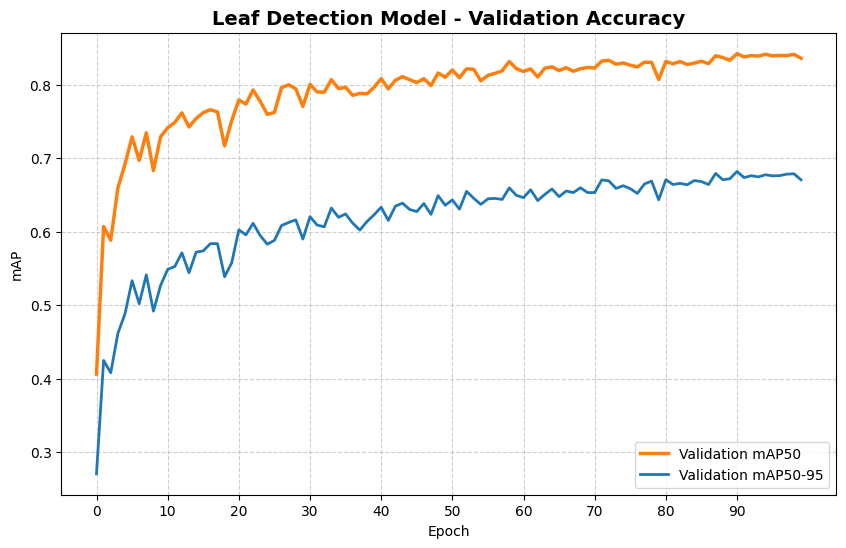

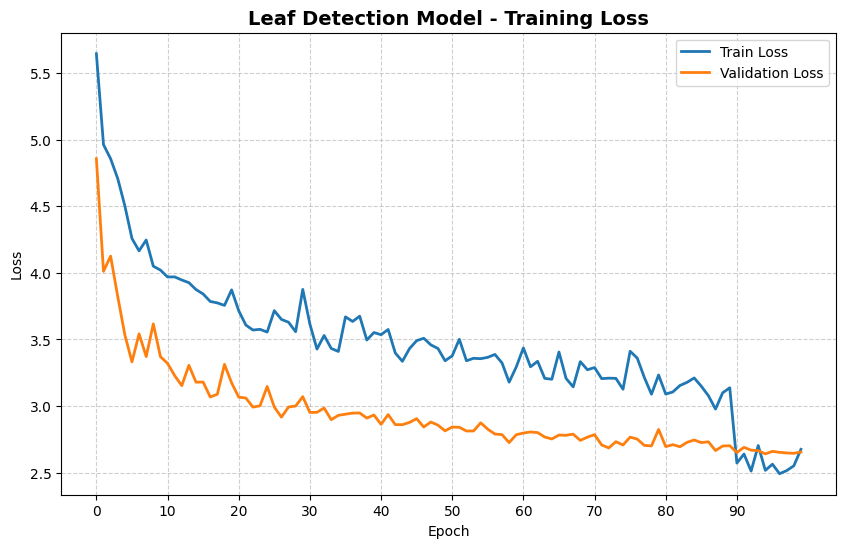

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# ================== ตั้งค่าพาธใหม่ ==================
RUN_PATH = '/content/runs/detect/LeafDetection/LeafModel_v2'

# หา results.csv
csv_file = os.path.join(RUN_PATH, 'results.csv')

if os.path.exists(csv_file):
    df = pd.read_csv(csv_file)
    df.columns = df.columns.str.strip()   # ลบช่องว่างหัวตาราง

    print("✅ โหลดข้อมูลผลการเทรนสำเร็จ!")
    print(f"จำนวน Epoch ที่เทรนไป: {len(df)} epochs\n")

    # เตรียมข้อมูล
    val_accuracy = df['metrics/mAP50(B)']

    train_loss = df['train/box_loss'] + df['train/cls_loss'] + df['train/dfl_loss']
    val_loss = df['val/box_loss'] + df['val/cls_loss'] + df['val/dfl_loss']

    final_accuracy = val_accuracy.iloc[-1]

    # ================== กราฟ Accuracy ==================
    print(f'Accuracy (mAP50): {final_accuracy:.4f}\n')

    plt.figure(figsize=(10, 6))
    plt.plot(val_accuracy, color='#ff7f0e', linewidth=2.5, label='Validation mAP50')

    # เพิ่ม mAP50-95 ถ้ามี
    if 'metrics/mAP50-95(B)' in df.columns:
        plt.plot(df['metrics/mAP50-95(B)'], color='#1f77b4', linewidth=2, label='Validation mAP50-95')

    plt.title('Leaf Detection Model - Validation Accuracy', fontweight='bold', fontsize=14)
    plt.ylabel('mAP')
    plt.xlabel('Epoch')
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(range(0, len(val_accuracy), max(5, len(val_accuracy)//10)))
    plt.show()

    # ================== กราฟ Loss ==================
    plt.figure(figsize=(10, 6))
    plt.plot(train_loss, color='#1f77b4', linewidth=2, label='Train Loss')
    plt.plot(val_loss, color='#ff7f0e', linewidth=2, label='Validation Loss')
    plt.title('Leaf Detection Model - Training Loss', fontweight='bold', fontsize=14)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(range(0, len(train_loss), max(5, len(train_loss)//10)))
    plt.show()

else:
    print("❌ ไม่พบไฟล์ results.csv")
    print("ตรวจสอบโฟลเดอร์:")
    !ls -la "{RUN_PATH}"

📊 Confusion Matrix Normalized



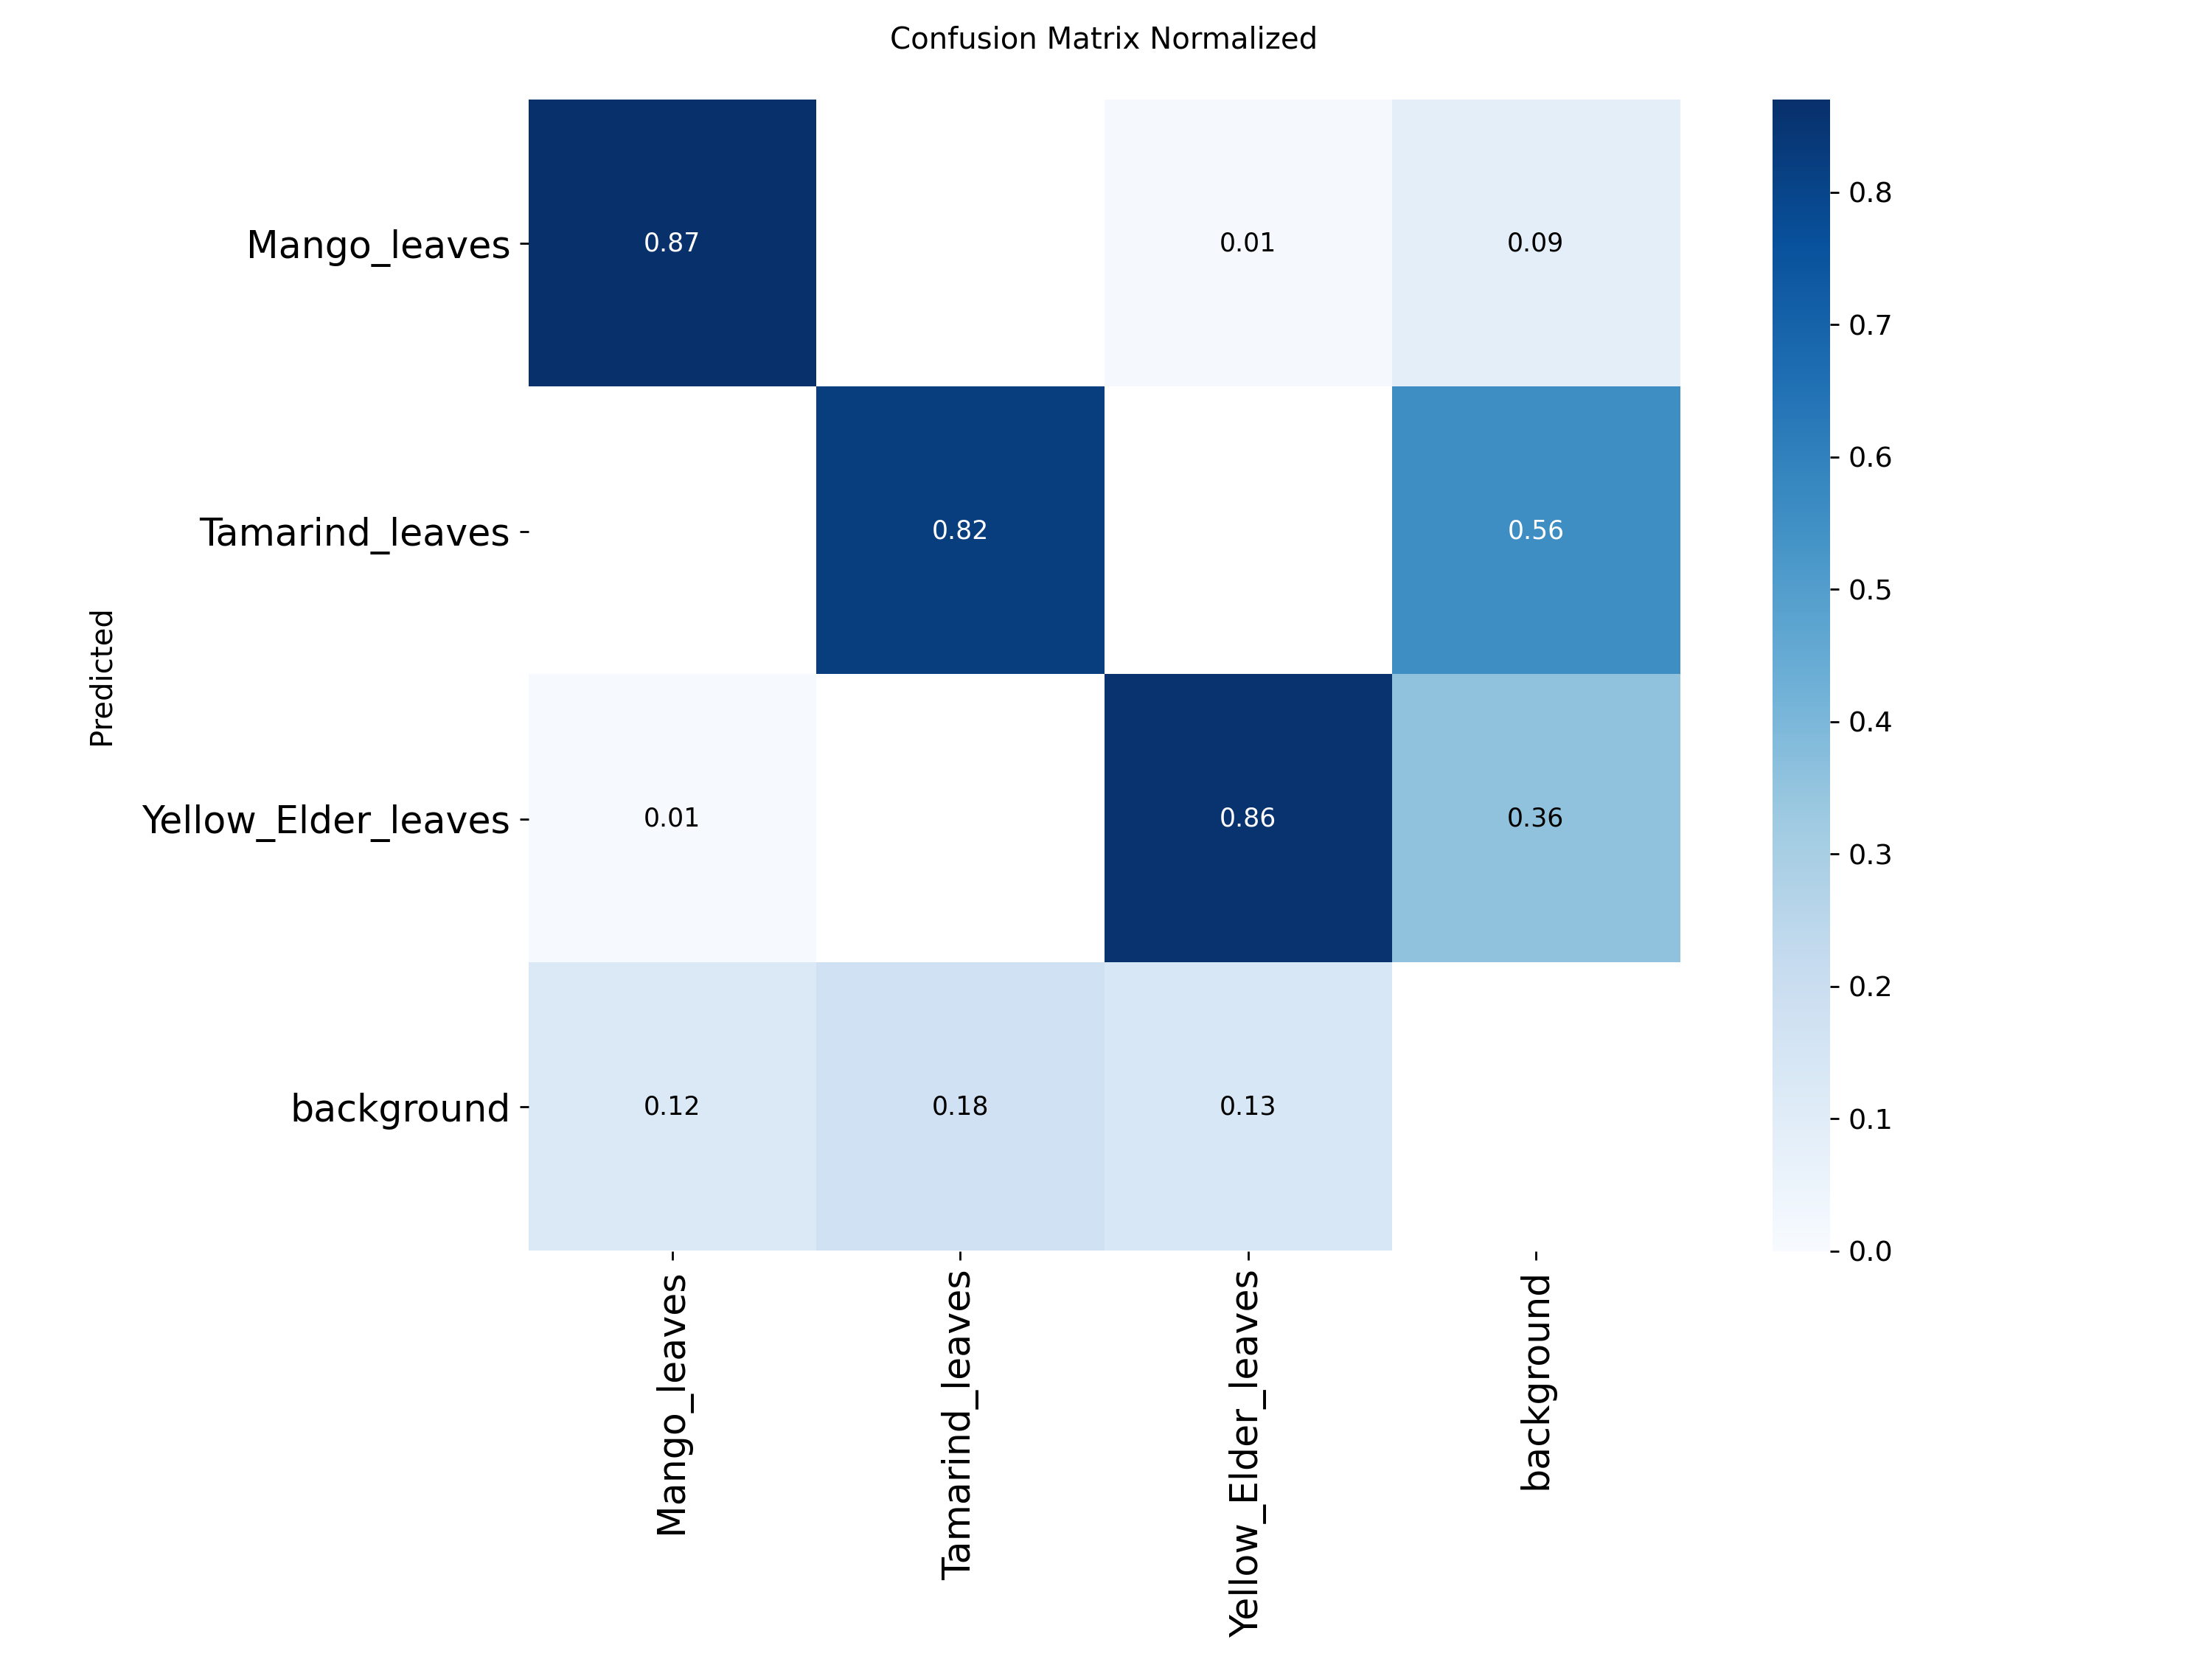

✅ แสดง Confusion Matrix สำเร็จ (Normalized)


In [17]:
import os
from IPython.display import Image, display

# Path ของโปรเจกต์คุณ
RESULT_PATH = '/content/runs/detect/LeafDetection/LeafModel_v2'

# Path ของ Confusion Matrix
confusion_path = f'{RESULT_PATH}/confusion_matrix_normalized.png'

print("📊 Confusion Matrix Normalized\n")

if os.path.exists(confusion_path):
    display(Image(filename=confusion_path, width=850))
    print("✅ แสดง Confusion Matrix สำเร็จ (Normalized)")
else:
    print("❌ ไม่พบไฟล์ confusion_matrix_normalized.png")
    print(f"ตรวจสอบ path: {confusion_path}")
    # แสดงรายการไฟล์ที่มีเพื่อตรวจสอบ
    !ls "{RESULT_PATH}" | grep -E "confusion|matrix"